# Data Warehousing and Business Intelligence Coursework - Group 6
## Anahita Hessami (Part A) - Morteza Nateghi (Part B) - Kamran Rzayev (Part C)
---

### This report contains two parts:
*   #### Coding & Results
*   #### Further Visualizations (for parts A and C)

# Coding
---

In [1]:
# Install and import required packages
!pip install yfinance yahoofinancials pandas numpy matplotlib seaborn scipy -q

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from yahoofinancials import YahooFinancials
from datetime import datetime

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})


## Part A

In [2]:
# Part A-1
# Extract S&P 500 Tickers from Wikipedia

SP500_WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {'User-Agent': 'Mozilla/5.0'}
sp500_info = pd.read_html(SP500_WIKI_URL, storage_options=headers)[0]

sp500_info.rename(columns={
    "Symbol": "Ticker",
    "Security": "Company",
    "GICS Sector": "Sector",
    "GICS Sub-Industry": "Sub_Industry"
}, inplace=True)

# Yahoo Finance uses '-' not '.' (e.g. BRK.B -> BRK-B)
sp500_info["Ticker"] = sp500_info["Ticker"].str.replace(".", "-", regex=False)
tickers = sp500_info["Ticker"].tolist()

print(f"{len(tickers)} tickers extracted.")
print(sp500_info[["Ticker", "Company", "Sector", "Headquarters Location", "Founded"]].head(10).to_string(index=False))

503 tickers extracted.
Ticker                Company                 Sector   Headquarters Location     Founded
   MMM                     3M            Industrials   Saint Paul, Minnesota        1902
   AOS            A. O. Smith            Industrials    Milwaukee, Wisconsin        1916
   ABT    Abbott Laboratories            Health Care North Chicago, Illinois        1888
  ABBV                 AbbVie            Health Care North Chicago, Illinois 2013 (1888)
   ACN              Accenture Information Technology         Dublin, Ireland        1989
  ADBE             Adobe Inc. Information Technology    San Jose, California        1982
   AMD Advanced Micro Devices Information Technology Santa Clara, California        1969
   AES        AES Corporation              Utilities     Arlington, Virginia        1981
   AFL                  Aflac             Financials       Columbus, Georgia        1955
     A   Agilent Technologies            Health Care Santa Clara, California        199

In [3]:
# Part A-2
# Load Daily Market Data with yfinance

START_DATE = "2022-01-01"
END_DATE   = "2025-01-01"

print(f" Downloading daily Close prices via yfinance …")
print(f"    Period  : {START_DATE} → {END_DATE}")
print(f"    Tickers : {len(tickers)}")
print()

raw_prices = yf.download(
    tickers     = tickers,
    start       = START_DATE,
    end         = END_DATE,
    auto_adjust = True,
    progress    = True,
    threads     = True
)["Close"]

# ── Transpose: rows = tickers, columns = trading days ────────────────────────
raw_prices = raw_prices.T
print(f"\n yfinance download complete.")
print(f"  Shape after transpose : {raw_prices.shape}  (rows=tickers, cols=trading days)")
print()
print("First 5 rows (tickers) × first 5 trading days:")
print(raw_prices.iloc[:5, :5].round(2))

    Period  : 2022-01-01 → 2025-01-01
    Tickers : 503



[                       0%                       ]  2 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")
[***************       32%                       ]  162 of 503 completed$Q: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['SNDK', 'Q']: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")



 yfinance download complete.
  Shape after transpose : (503, 753)  (rows=tickers, cols=trading days)

First 5 rows (tickers) × first 5 trading days:
Date    2022-01-03  2022-01-04  2022-01-05  2022-01-06  2022-01-07
Ticker                                                            
A           151.70      146.57      144.06      144.57      140.72
AAPL        178.10      175.84      171.17      168.31      168.47
ABBV        114.89      114.67      115.28      114.73      114.44
ABNB        172.68      170.80      162.25      159.75      166.05
ABT         127.55      124.55      123.99      123.97      124.35


In [4]:
# Part A-3
# Identify and Remove Invalid Data
# Work on a copy; transpose back to (dates × tickers) for cleaning, then re-transpose so the cleaned result stays (tickers × dates).

prices = raw_prices.T.copy()    # (trading days × tickers) for cleaning operations

print("=" * 55)
print("  DATA QUALITY AUDIT")
print("=" * 55)
print(f"\nRaw shape (dates × tickers) : {prices.shape}")

# Drop tickers with NO data at all
all_nan_tickers = prices.columns[prices.isnull().all()].tolist()
prices.drop(columns=all_nan_tickers, inplace=True)
print(f"All-NaN tickers    : {len(all_nan_tickers)} removed → {all_nan_tickers[:10]}")

# Drop tickers with > 10% missing values
MISSING_THRESHOLD = 0.10
missing_frac = prices.isnull().mean()
high_missing  = missing_frac[missing_frac > MISSING_THRESHOLD].index.tolist()
prices.drop(columns=high_missing, inplace=True)
print(f"High-missing (>10%): {len(high_missing)} removed → {high_missing[:10]}")

# Forward-fill then backward-fill residual NaNs (public holidays etc.)
before_fill = prices.isnull().sum().sum()
prices.ffill(inplace=True)
prices.bfill(inplace=True)
after_fill  = prices.isnull().sum().sum()
print(f"Residual NaNs      : {before_fill} → filled → {after_fill} remaining")

# Drop fully-NaN rows (dates)
prices.dropna(how="all", inplace=True)

# Remove near-zero variance tickers
low_var_tickers = prices.columns[prices.std() < 0.01].tolist()
prices.drop(columns=low_var_tickers, inplace=True)
print(f"Near-zero variance : {len(low_var_tickers)} removed")

print(f"\n Clean data shape (dates × tickers) : {prices.shape}")
print(f"  Date range : {prices.index.min().date()} → {prices.index.max().date()}")
print(f"  Tickers retained : {prices.shape[1]}")

clean_tickers = prices.columns.tolist()

  DATA QUALITY AUDIT

Raw shape (dates × tickers) : (753, 503)
All-NaN tickers    : 2 removed → ['Q', 'SNDK']
High-missing (>10%): 5 removed → ['GEHC', 'GEV', 'KVUE', 'SOLV', 'VLTO']
Residual NaNs      : 11 → filled → 0 remaining
Near-zero variance : 0 removed

 Clean data shape (dates × tickers) : (753, 496)
  Date range : 2022-01-03 → 2024-12-31
  Tickers retained : 496


In [5]:
# Part A-4
# Calculate Daily Returns
# Daily Return = (Price_today − Price_yesterday) / Price_yesterday

daily_returns = prices.pct_change().dropna()

print("=" * 55)
print("  DAILY RETURNS")
print("=" * 55)
print(f"\nShape           : {daily_returns.shape}")
print(f"Date range      : {daily_returns.index.min().date()} → {daily_returns.index.max().date()}")
print(f"\nDescriptive statistics (first 5 tickers):")
print(daily_returns.iloc[:, :5].describe().round(5))

# Download S&P 500 INDEX for Beta calculation
index_prices  = yf.download("^GSPC", start=START_DATE, end=END_DATE,
                              auto_adjust=True, progress=False)["Close"]
index_returns = index_prices.pct_change().dropna()
index_returns.name = "SP500"

# Align dates
aligned_dates = daily_returns.index.intersection(index_returns.index)
daily_returns = daily_returns.loc[aligned_dates]
index_returns = index_returns.loc[aligned_dates]

  DAILY RETURNS

Shape           : (752, 496)
Date range      : 2022-01-04 → 2024-12-31

Descriptive statistics (first 5 tickers):
Ticker          A       AAPL       ABBV       ABNB        ABT
count   752.00000  752.00000  752.00000  752.00000  752.00000
mean     -0.00000    0.00059    0.00061    0.00007   -0.00011
std       0.01866    0.01707    0.01386    0.02947    0.01372
min      -0.09665   -0.05868   -0.12566   -0.13425   -0.06544
25%      -0.01083   -0.00844   -0.00619   -0.01554   -0.00798
50%      -0.00011    0.00112    0.00100    0.00021   -0.00019
75%       0.01084    0.00975    0.00817    0.01596    0.00715
max       0.08721    0.08897    0.06361    0.13353    0.07816


In [6]:
# Part A-5
# Calculate Beta for each stock

market_var = index_returns.squeeze().var()    # Variance(R_m) — constant across all stocks

betas = {}
for ticker in clean_tickers:
    stock_ret     = daily_returns[ticker]
    covariance    = stock_ret.cov(index_returns.squeeze())     # Covariance(R_e, R_m)
    betas[ticker] = covariance / market_var          # β = Cov(R_e, R_m) / Var(R_m)

beta_series = pd.Series(betas, name="Beta").sort_values()

print("=" * 55)
print("  BETA VALUES")
print("=" * 55)
print(f"\nBeta statistics:")
print(beta_series.describe().round(4))
print(f"\nStocks with Beta > 1.5  (highly aggressive) : {(beta_series > 1.5).sum()}")
print(f"Stocks with 0.8 ≤ Beta ≤ 1.2 (market-like) : {((beta_series >= 0.8) & (beta_series <= 1.2)).sum()}")
print(f"Stocks with Beta < 0.5  (highly defensive)  : {(beta_series < 0.5).sum()}")
print(f"\nTop 10 highest-Beta stocks:\n{beta_series.nlargest(10).round(4).to_string()}")
print(f"\nTop 10 lowest-Beta stocks:\n{beta_series.nsmallest(10).round(4).to_string()}")



  BETA VALUES

Beta statistics:
count    496.0000
mean       0.9437
std        0.4318
min        0.1332
25%        0.6330
50%        0.9117
75%        1.1557
max        3.2941
Name: Beta, dtype: float64

Stocks with Beta > 1.5  (highly aggressive) : 48
Stocks with 0.8 ≤ Beta ≤ 1.2 (market-like) : 196
Stocks with Beta < 0.5  (highly defensive)  : 72

Top 10 highest-Beta stocks:
CVNA    3.2941
COIN    2.9610
XYZ     2.5448
NVDA    2.2685
APP     2.2619
TTD     2.2371
PLTR    2.1896
MPWR    2.1341
AMD     2.0647
VRT     2.0609

Top 10 lowest-Beta stocks:
GIS    0.1332
CPB    0.1337
SJM    0.1966
HRL    0.2366
LMT    0.2439
JNJ    0.2466
KHC    0.2497
MRK    0.2588
HSY    0.2718
CAG    0.2760


In [7]:
# Part A-6
# Calculate Annual Volatility

# Formula: Annual Volatility = σ_daily × √252
# 252 = conventional number of trading days in a year.

TRADING_DAYS = 252

annual_vol = daily_returns.std() * np.sqrt(TRADING_DAYS)
annual_vol.name = "Annual_Volatility"

print("=" * 55)
print("  ANNUAL VOLATILITY")
print("=" * 55)
print(f"\nAnnual Volatility statistics:")
print(annual_vol.describe().round(4))
print(f"\nTop 10 most volatile stocks:")
print(annual_vol.nlargest(10).apply(lambda x: f"{x*100:.2f}%").to_string())
print(f"\nTop 10 least volatile stocks:")
print(annual_vol.nsmallest(10).apply(lambda x: f"{x*100:.2f}%").to_string())



  ANNUAL VOLATILITY

Annual Volatility statistics:
count    496.0000
mean       0.3143
std        0.1148
min        0.1562
25%        0.2401
50%        0.2850
75%        0.3573
max        1.3410
Name: Annual_Volatility, dtype: float64

Top 10 most volatile stocks:
Ticker
CVNA    134.10%
COIN     95.38%
SMCI     90.20%
APP      78.84%
PLTR     69.09%
XYZ      65.38%
HOOD     65.18%
TTD      64.77%
VRT      62.98%
TSLA     61.30%

Top 10 least volatile stocks:
Ticker
KO       15.62%
JNJ      16.38%
PEP      17.04%
MCD      17.35%
CL       17.37%
BRK-B    17.38%
PG       17.59%
RSG      17.80%
MDLZ     18.50%
KMB      18.56%


In [8]:
# Part A-7
# Combine Metrics & Segment Stocks by Risk Profile

metrics_df = pd.DataFrame({
    "Mean_Daily_Return": daily_returns.mean(),
    "Beta"             : beta_series,
    "Annual_Volatility": annual_vol
})

metrics_df = metrics_df.merge(
    sp500_info[["Ticker","Company","Sector"]].set_index("Ticker"),
    left_index=True, right_index=True, how="left"
)

# Rule-based Risk Segmentation using quantile thresholds
beta_low   = metrics_df["Beta"].quantile(0.33)
beta_high  = metrics_df["Beta"].quantile(0.67)
vol_low    = metrics_df["Annual_Volatility"].quantile(0.33)
vol_high   = metrics_df["Annual_Volatility"].quantile(0.67)

def assign_segment(row):
    b = row["Beta"]
    v = row["Annual_Volatility"]
    if   b <= beta_low  and v <= vol_low:   return "  Conservative"
    elif b >= beta_high and v >= vol_high:  return "  Aggressive"
    elif b <= beta_low  and v >= vol_high:  return "  High-Vol / Low-Beta"
    elif b >= beta_high and v <= vol_low:   return "  Market-Sensitive / Stable"
    else:                                   return "  Balanced / Moderate"

metrics_df["Risk_Segment"] = metrics_df.apply(assign_segment, axis=1)

print("=" * 55)
print("  RISK SEGMENT DISTRIBUTION")
print("=" * 55)
print()
print(metrics_df["Risk_Segment"].value_counts().to_string())
print()

segment_stats = metrics_df.groupby("Risk_Segment")[
    ["Mean_Daily_Return","Beta","Annual_Volatility"]
].mean().round(4)
segment_stats["Mean_Daily_Return"] = segment_stats["Mean_Daily_Return"] * 100
segment_stats["Annual_Volatility"] = segment_stats["Annual_Volatility"] * 100
segment_stats.columns = ["Mean Daily Return (%)", "Beta", "Annual Volatility (%)"]

print("Average metrics per risk segment:")
print(segment_stats.to_string())

print("\n\nSector composition per segment (top-3 sectors):")
for seg in metrics_df["Risk_Segment"].unique():
    top_sectors = (metrics_df.loc[metrics_df["Risk_Segment"] == seg, "Sector"]
                   .value_counts().head(3))
    print(f"\n  {seg}")
    for sector, cnt in top_sectors.items():
        print(f"    {sector:<40s} {cnt:>3d} stocks")

  RISK SEGMENT DISTRIBUTION

Risk_Segment
Balanced / Moderate          249
Aggressive                   119
Conservative                 111
High-Vol / Low-Beta           16
Market-Sensitive / Stable      1

Average metrics per risk segment:
                           Mean Daily Return (%)    Beta  Annual Volatility (%)
Risk_Segment                                                                   
Aggressive                                  0.06  1.5070                  45.33
Balanced / Moderate                         0.04  0.9036                  28.84
Conservative                                0.03  0.4778                  21.57
High-Vol / Low-Beta                         0.05  0.5977                  37.09
Market-Sensitive / Stable                   0.08  1.1474                  25.34


Sector composition per segment (top-3 sectors):

    Balanced / Moderate
    Industrials                               54 stocks
    Financials                                45 stocks
    Health 

## Part B: Customer segmentation

For parts B-1, B-2, B-4 and B-5:  **Please see the report.**

In [9]:
# importing packages
import pandas as pd
from io import StringIO
import numpy as np
import yfinance as yf
from yahoofinancials import YahooFinancials
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
import matplotlib.cm as cm
import os
os.environ["OMP_NUM_THREADS"] = "2"

B-3: Agglomerative Clustering

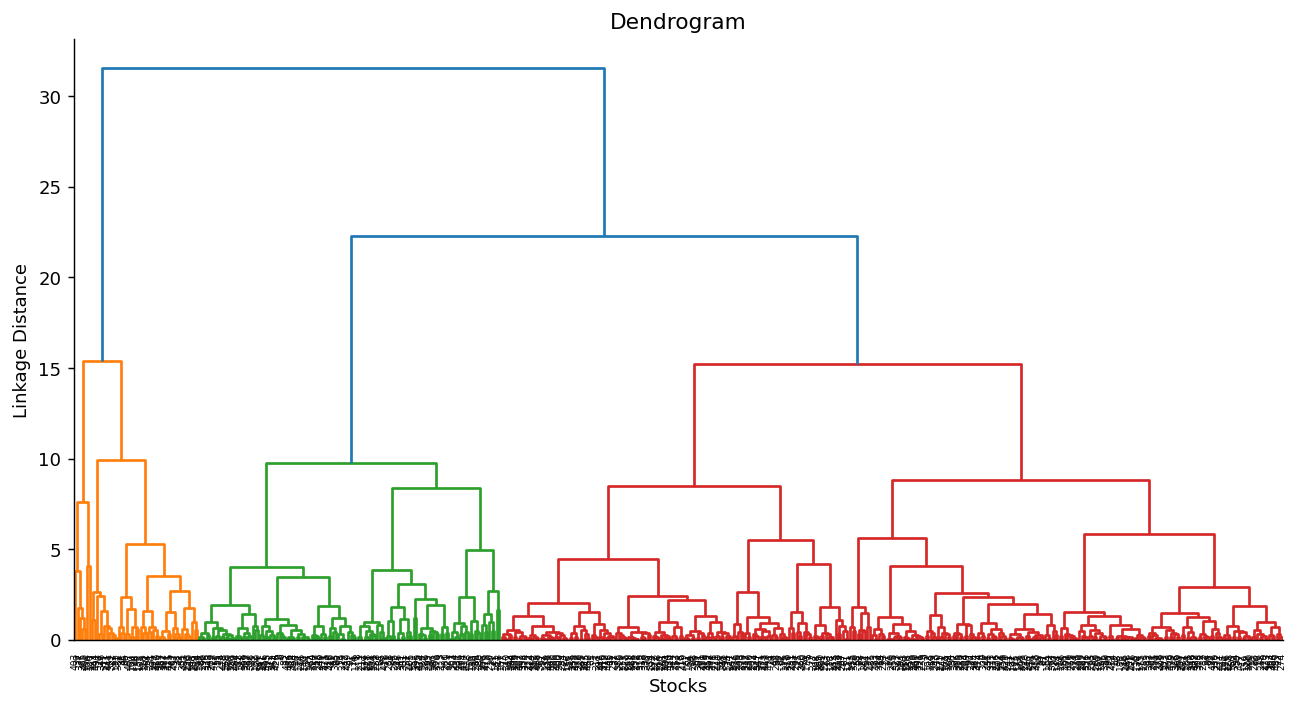

Number of clusters: 2, Silhouette Score: 0.5206
Number of clusters: 3, Silhouette Score: 0.3115
Number of clusters: 4, Silhouette Score: 0.3168
Number of clusters: 5, Silhouette Score: 0.2603
Number of clusters: 6, Silhouette Score: 0.2629


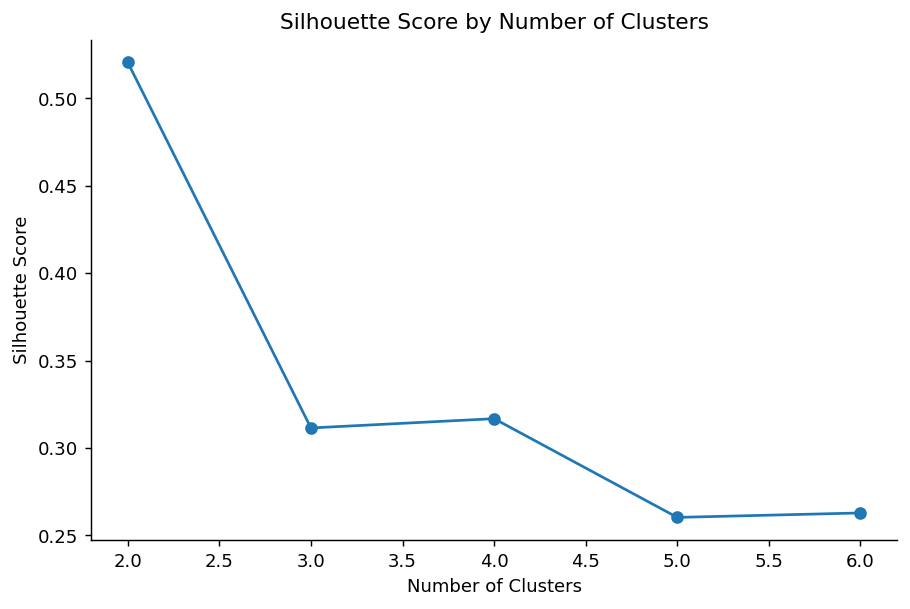

      Mean_Daily_Return      Beta  Annual_Volatility  Cluster
A             -0.000002  1.024801           0.296259        2
AAPL           0.000591  1.210689           0.270935        1
ABBV           0.000610  0.299097           0.219958        1
ABNB           0.000074  1.666256           0.467875        2
ABT           -0.000106  0.672316           0.217839        1

Cluster
0     51
1    321
2    124
Name: count, dtype: int64

         Mean_Daily_Return      Beta  Annual_Volatility
Cluster                                                
0                 0.001541  1.652903           0.522985
1                 0.000445  0.723160           0.259383
2                -0.000023  1.222887           0.370634


In [10]:
# Scale the features
df_features = metrics_df[["Mean_Daily_Return", "Beta", "Annual_Volatility"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# Dendrogram
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Stocks")
plt.ylabel("Linkage Distance")
plt.show()

# Silhouette scores for different numbers of clusters
silhouette_scores = {}

for n in range(2, 7):
    model = AgglomerativeClustering(n_clusters=n, linkage="ward")
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[n] = score
    print(f"Number of clusters: {n}, Silhouette Score: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

# Final model
best_n = 3  # replace with your chosen number
agg_model = AgglomerativeClustering(n_clusters=best_n, linkage="ward")
df_features["Cluster"] = agg_model.fit_predict(X_scaled)

# Inspect results
print(df_features.head())
print()
print(df_features["Cluster"].value_counts().sort_index())

# Cluster profiles
cluster_profile = df_features.groupby("Cluster")[["Mean_Daily_Return","Beta","Annual_Volatility"]].mean()
print()
print(cluster_profile)

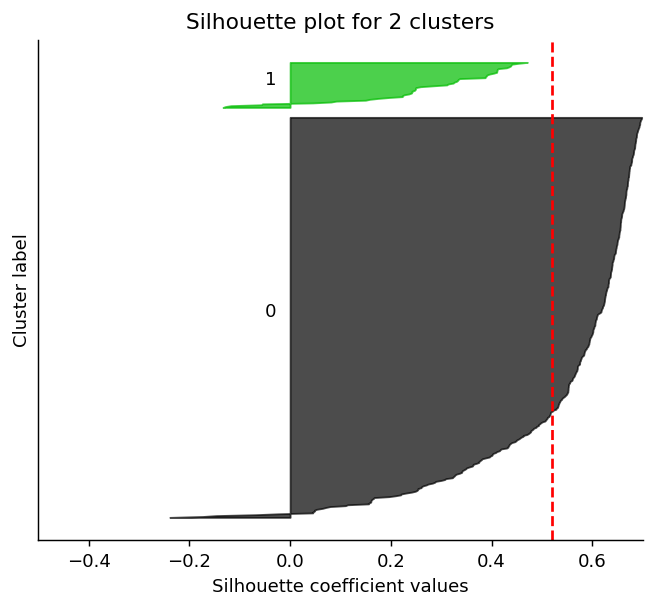

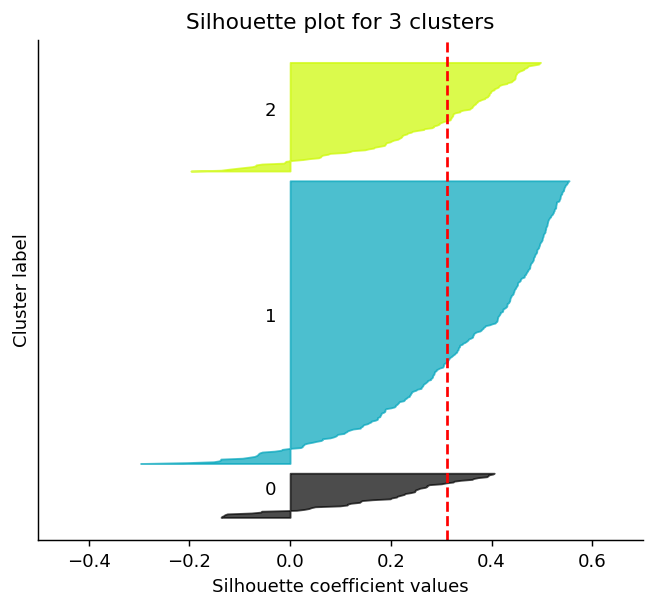

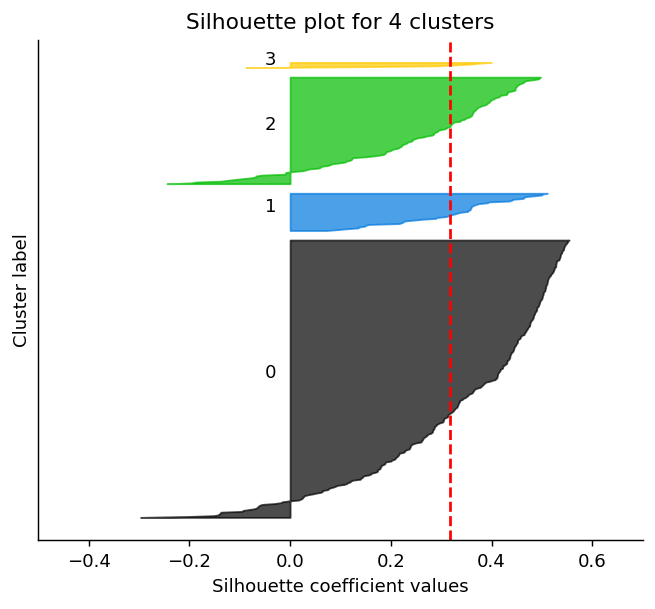

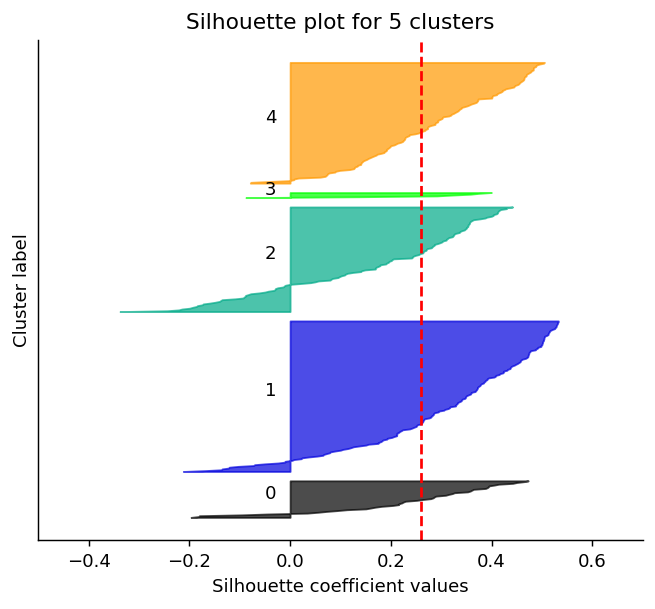

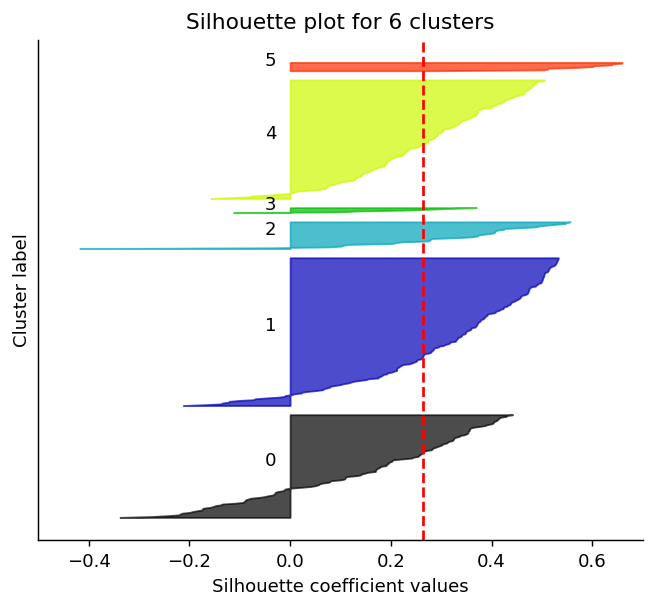

In [11]:
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:

    fig, ax = plt.subplots(figsize=(6, 5))

    # Fit model
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    cluster_labels = clusterer.fit_predict(X_scaled)

    # Compute silhouette values
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10

    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    ax.set_title(f"Silhouette plot for {n_clusters} clusters")
    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # Average silhouette line
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])
    ax.set_xlim([-0.5, 0.7])

    plt.show()

B-6 K-Means Clustering

K = 2, Inertia = 935.25, Silhouette Score = 0.4622
K = 3, Inertia = 720.59, Silhouette Score = 0.3110
K = 4, Inertia = 577.97, Silhouette Score = 0.3260
K = 5, Inertia = 474.06, Silhouette Score = 0.2985
K = 6, Inertia = 408.48, Silhouette Score = 0.2914



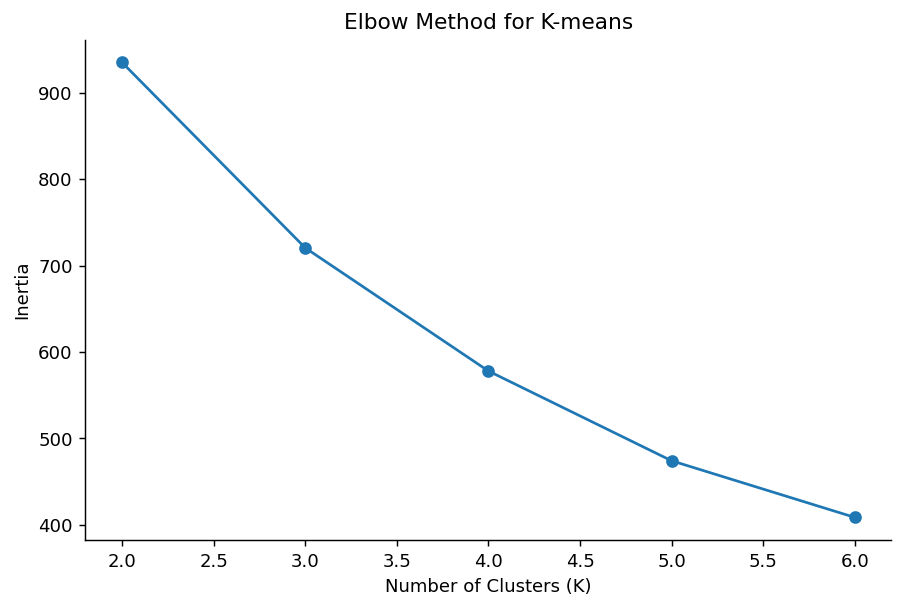

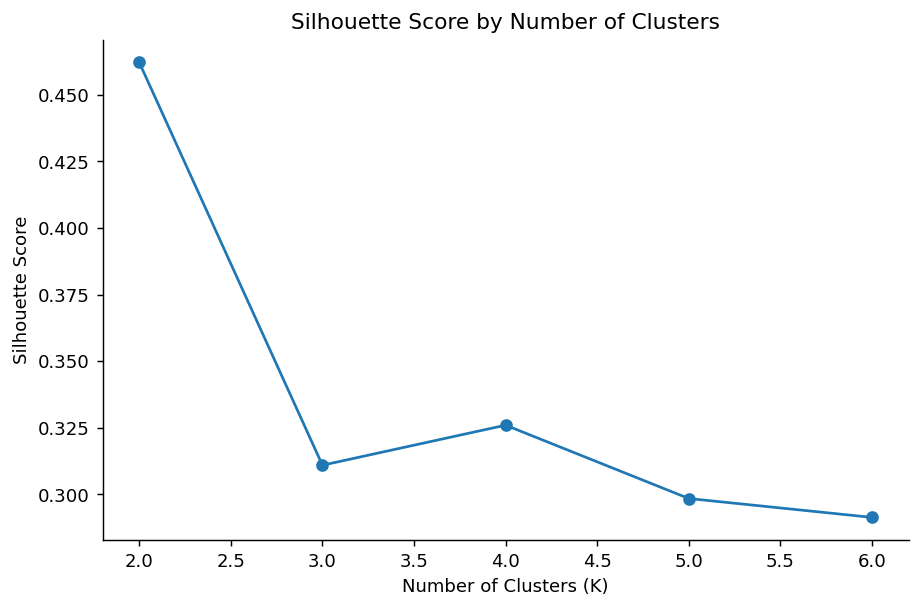

      Mean_Daily_Return      Beta  Annual_Volatility  Cluster  KMeans_Cluster
A             -0.000002  1.024801           0.296259        2               0
AAPL           0.000591  1.210689           0.270935        1               0
ABBV           0.000610  0.299097           0.219958        1               1
ABNB           0.000074  1.666256           0.467875        2               0
ABT           -0.000106  0.672316           0.217839        1               1

KMeans_Cluster
0    157
1    290
2     49
Name: count, dtype: int64

                Mean_Daily_Return      Beta  Annual_Volatility
KMeans_Cluster                                                
0                        0.000048  1.170006           0.359858
1                        0.000469  0.692434           0.252778
2                        0.001530  1.705586           0.532441


In [12]:
# Scale the features
scaler = StandardScaler()
X = metrics_df[["Mean_Daily_Return", "Beta", "Annual_Volatility"]]
X_scaled = scaler.fit_transform(X)

# Elbow method and silhouette score
inertia = []
silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores[k] = silhouette_score(X_scaled, cluster_labels)

    print(f"K = {k}, Inertia = {kmeans.inertia_:.2f}, Silhouette Score = {silhouette_scores[k]:.4f}")

print()

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), inertia, marker="o")
plt.title("Elbow Method for K-means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

# Final K-means model
best_k = 3   # replace with your chosen K
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_features["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

# Inspect results
print(df_features.head())
print()
print(df_features["KMeans_Cluster"].value_counts().sort_index())

# Cluster profiles
kmeans_profile = df_features.groupby("KMeans_Cluster")[["Mean_Daily_Return", "Beta", "Annual_Volatility"]].mean()
print()
print(kmeans_profile)

## Part C: Please see the report.

---

# Further Visualisations


### Part A-4: Daily Returns of Stocks Overview

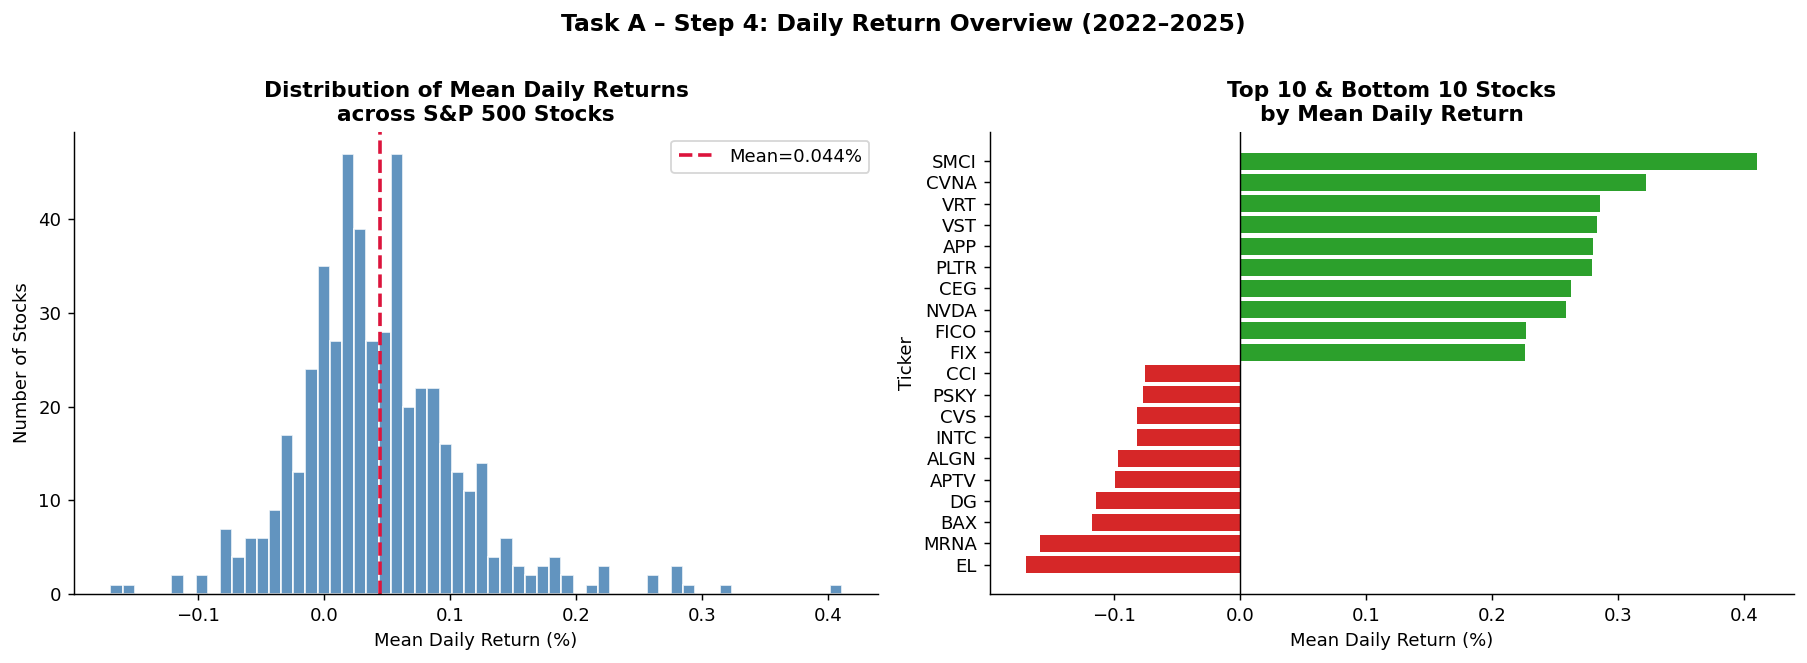


  Top 10 stocks by mean daily return:
Ticker
SMCI    0.4106%
CVNA    0.3219%
VRT     0.2857%
VST     0.2837%
APP     0.2802%
PLTR    0.2796%
CEG     0.2630%
NVDA    0.2588%
FICO    0.2267%
FIX     0.2264%

  Bottom 10 stocks by mean daily return:
Ticker
EL      -0.1695%
MRNA    -0.1582%
BAX     -0.1171%
DG      -0.1144%
APTV    -0.0991%
ALGN    -0.0966%
INTC    -0.0817%
CVS     -0.0816%
PSKY    -0.0767%
CCI     -0.0755%


In [13]:
# Visualisation
mean_daily_ret = daily_returns.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mean_daily_ret * 100, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(mean_daily_ret.mean() * 100, color="crimson", lw=2, ls="--",
                label=f"Mean={mean_daily_ret.mean()*100:.3f}%")
axes[0].set_title("Distribution of Mean Daily Returns\nacross S&P 500 Stocks", fontweight="bold")
axes[0].set_xlabel("Mean Daily Return (%)")
axes[0].set_ylabel("Number of Stocks")
axes[0].legend()

top10    = mean_daily_ret.nlargest(10)
bottom10 = mean_daily_ret.nsmallest(10)
combined = pd.concat([top10, bottom10]).sort_values()
colours  = ["#d62728" if v < 0 else "#2ca02c" for v in combined.values]

axes[1].barh(combined.index, combined.values * 100, color=colours)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Top 10 & Bottom 10 Stocks\nby Mean Daily Return", fontweight="bold")
axes[1].set_xlabel("Mean Daily Return (%)")
axes[1].set_ylabel("Ticker")

plt.suptitle("Task A – Step 4: Daily Return Overview (2022–2025)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n  Top 10 stocks by mean daily return:")
print(top10.apply(lambda x: f"{x*100:.4f}%").to_string())
print("\n  Bottom 10 stocks by mean daily return:")
print(bottom10.apply(lambda x: f"{x*100:.4f}%").to_string())

### Part A-5: Stocks Beta Analysis

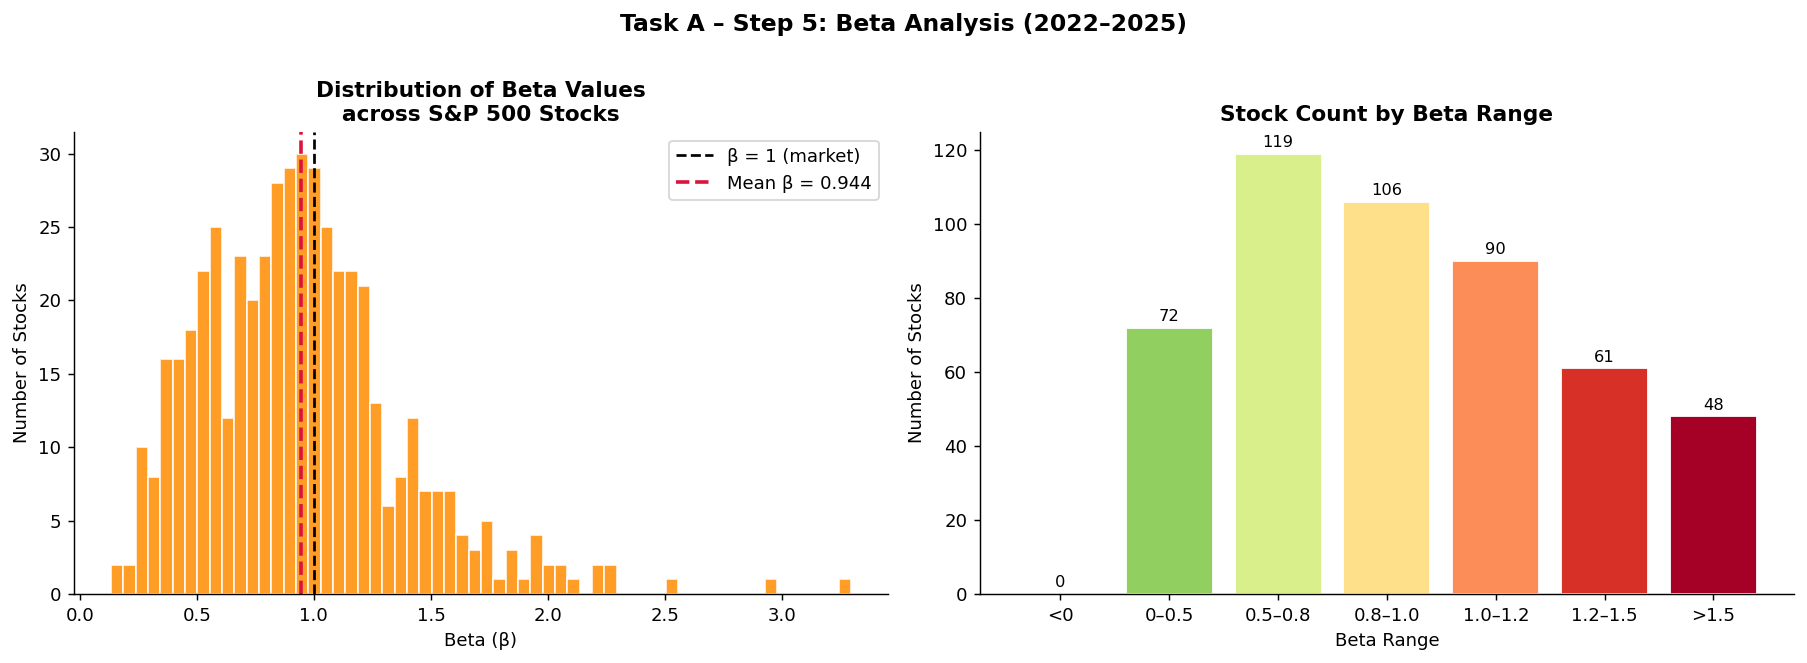

In [14]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(beta_series, bins=60, color="darkorange", edgecolor="white", alpha=0.85)
axes[0].axvline(1.0, color="black",  lw=1.5, ls="--", label="β = 1 (market)")
axes[0].axvline(beta_series.mean(), color="crimson", lw=2, ls="--",
                label=f"Mean β = {beta_series.mean():.3f}")
axes[0].set_title("Distribution of Beta Values\nacross S&P 500 Stocks", fontweight="bold")
axes[0].set_xlabel("Beta (β)")
axes[0].set_ylabel("Number of Stocks")
axes[0].legend()

beta_bins   = [-np.inf, 0, 0.5, 0.8, 1.0, 1.2, 1.5, np.inf]
beta_labels = ["<0", "0–0.5", "0.5–0.8", "0.8–1.0", "1.0–1.2", "1.2–1.5", ">1.5"]
counts = pd.cut(beta_series, bins=beta_bins, labels=beta_labels).value_counts().sort_index()

bar_colours = ["#1a9850","#91cf60","#d9ef8b","#fee08b","#fc8d59","#d73027","#a50026"]
axes[1].bar(counts.index, counts.values, color=bar_colours, edgecolor="white")
axes[1].set_title("Stock Count by Beta Range", fontweight="bold")
axes[1].set_xlabel("Beta Range")
axes[1].set_ylabel("Number of Stocks")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 1, str(v), ha="center", va="bottom", fontsize=9)

plt.suptitle("Task A – Step 5: Beta Analysis (2022–2025)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Part A-6: Stocks Annual Volatility Analysis

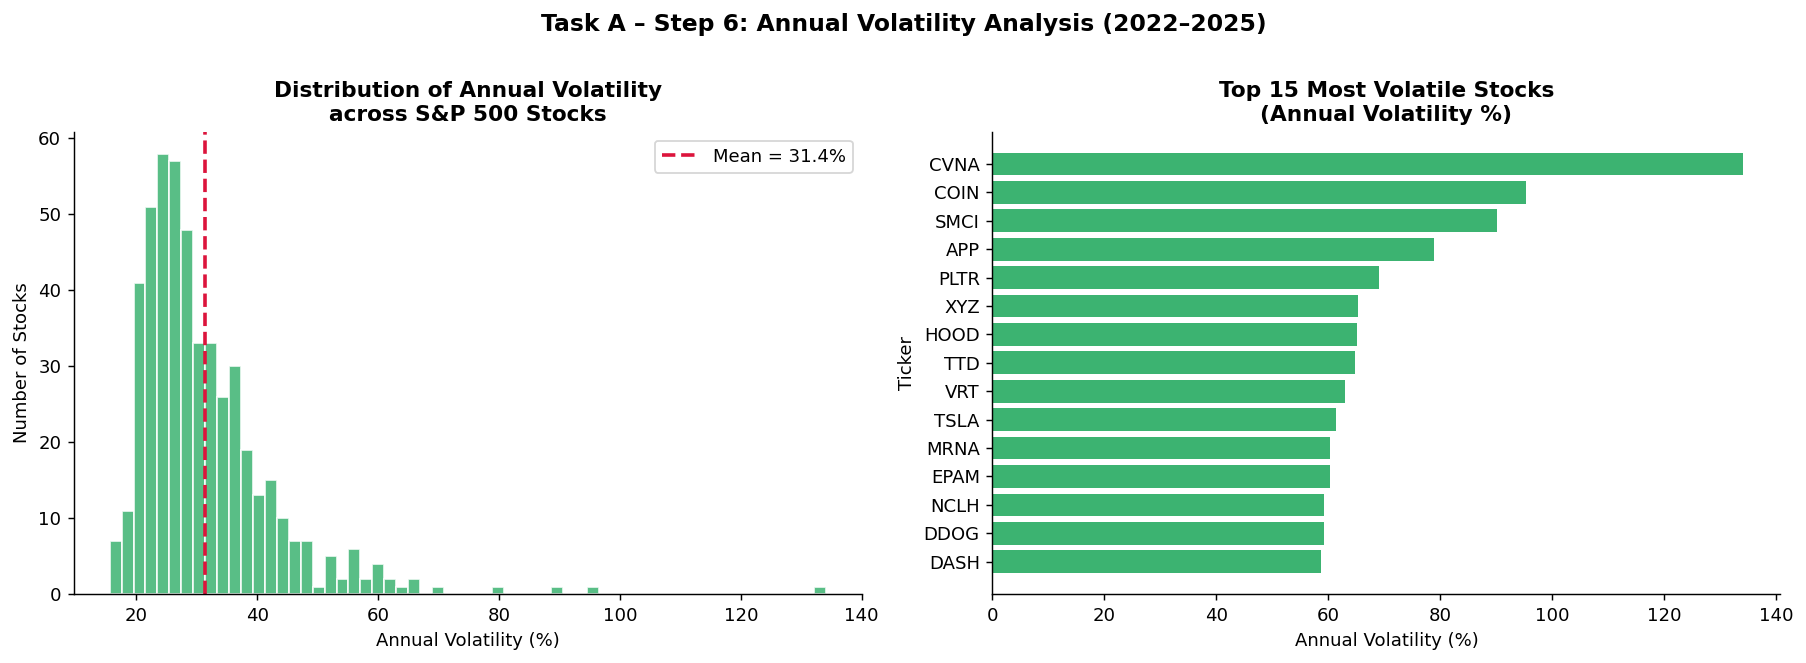

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(annual_vol * 100, bins=60, color="mediumseagreen", edgecolor="white", alpha=0.85)
axes[0].axvline(annual_vol.mean() * 100, color="crimson", lw=2, ls="--",
                label=f"Mean = {annual_vol.mean()*100:.1f}%")
axes[0].set_title("Distribution of Annual Volatility\nacross S&P 500 Stocks", fontweight="bold")
axes[0].set_xlabel("Annual Volatility (%)")
axes[0].set_ylabel("Number of Stocks")
axes[0].legend()

top15_vol = annual_vol.nlargest(15)
axes[1].barh(top15_vol.index[::-1], top15_vol.values[::-1] * 100, color="mediumseagreen")
axes[1].set_title("Top 15 Most Volatile Stocks\n(Annual Volatility %)", fontweight="bold")
axes[1].set_xlabel("Annual Volatility (%)")
axes[1].set_ylabel("Ticker")

plt.suptitle("Task A – Step 6: Annual Volatility Analysis (2022–2025)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Part A-7: Combined Metrics and Segmentation Visualisations

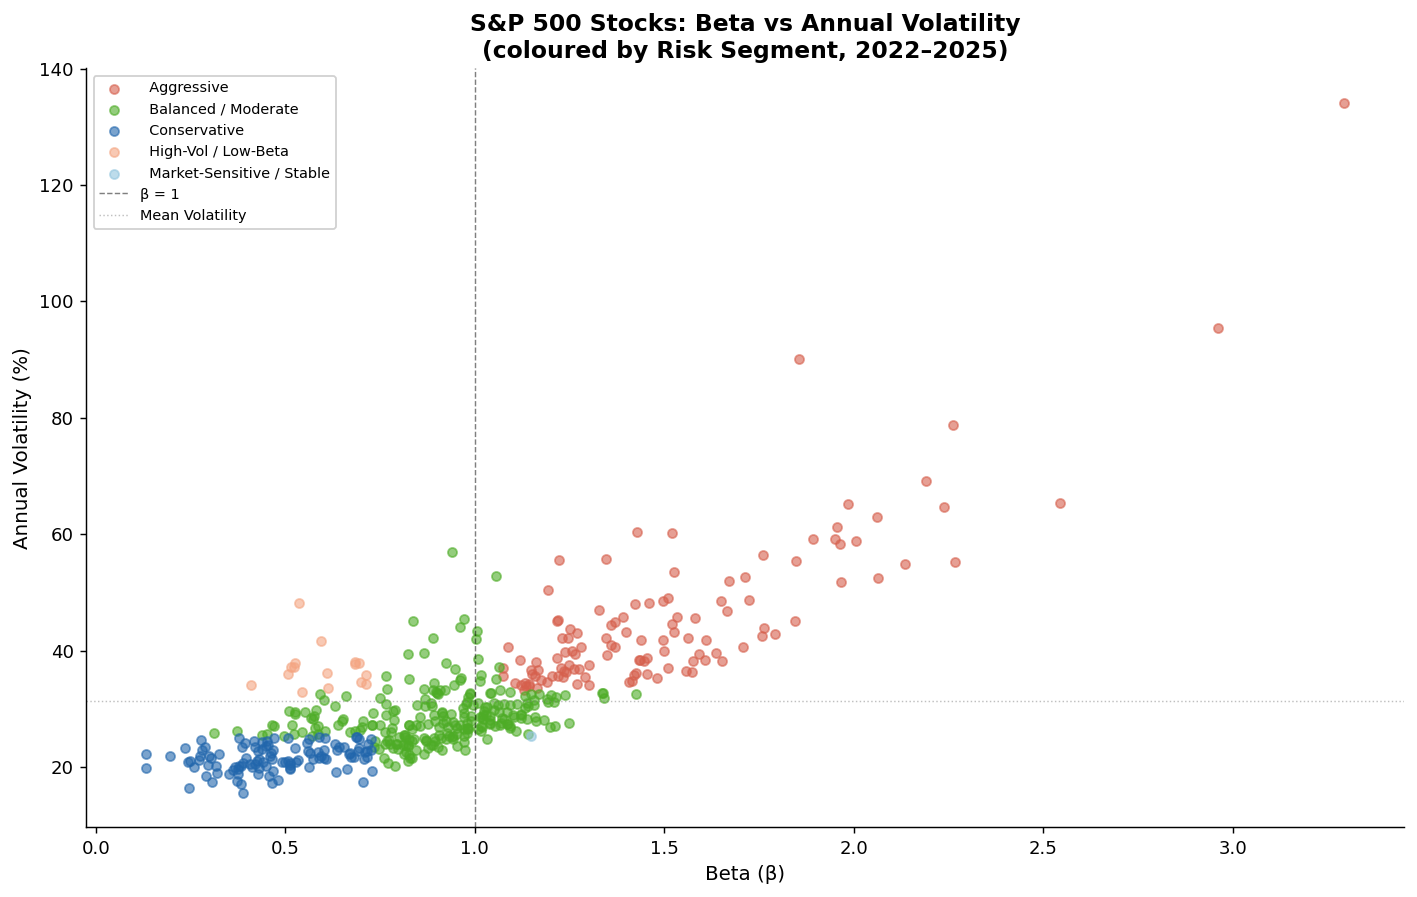

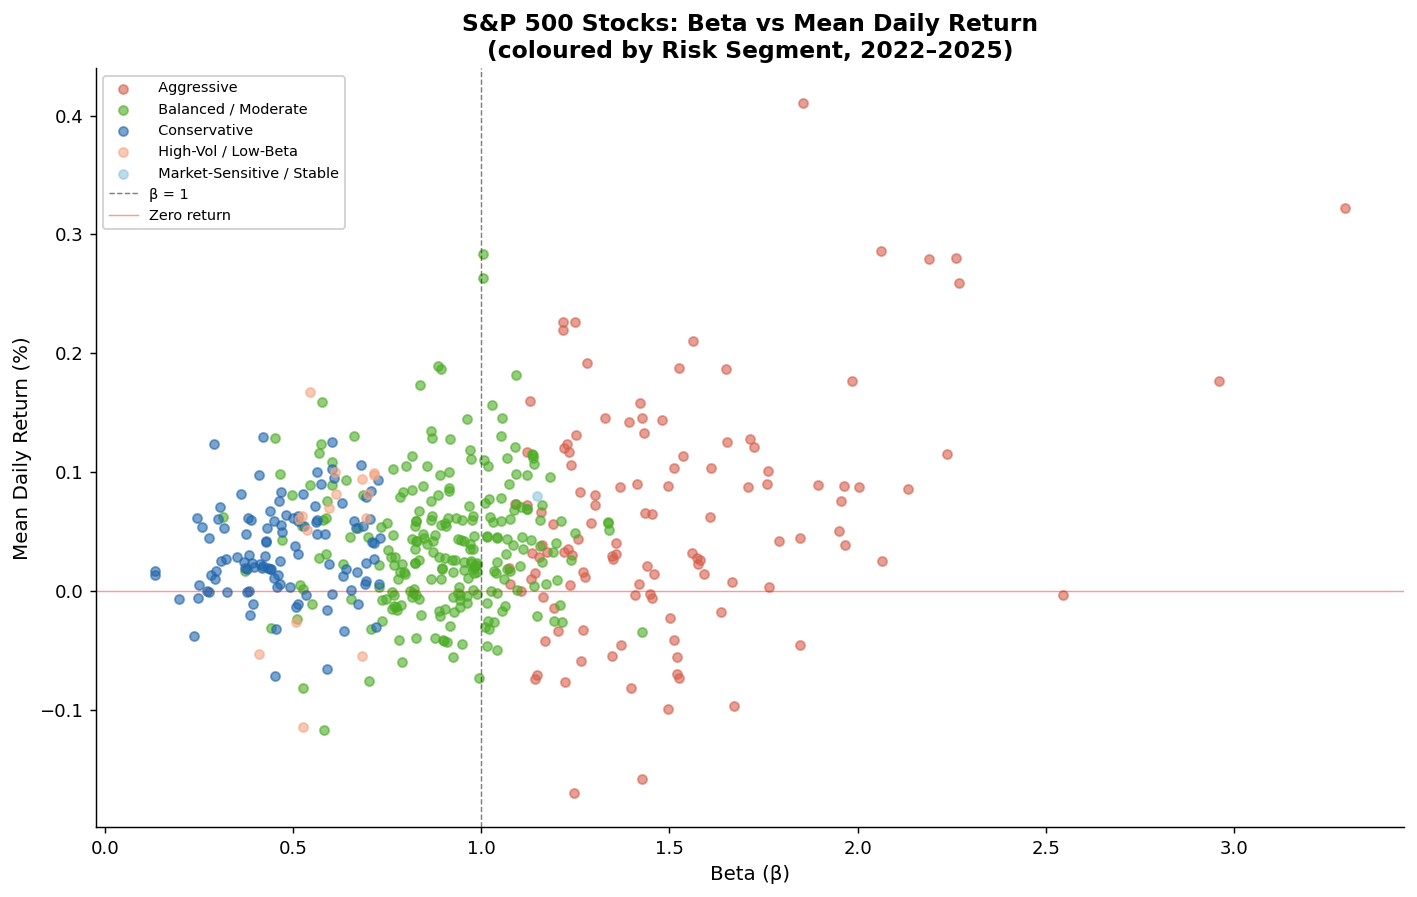

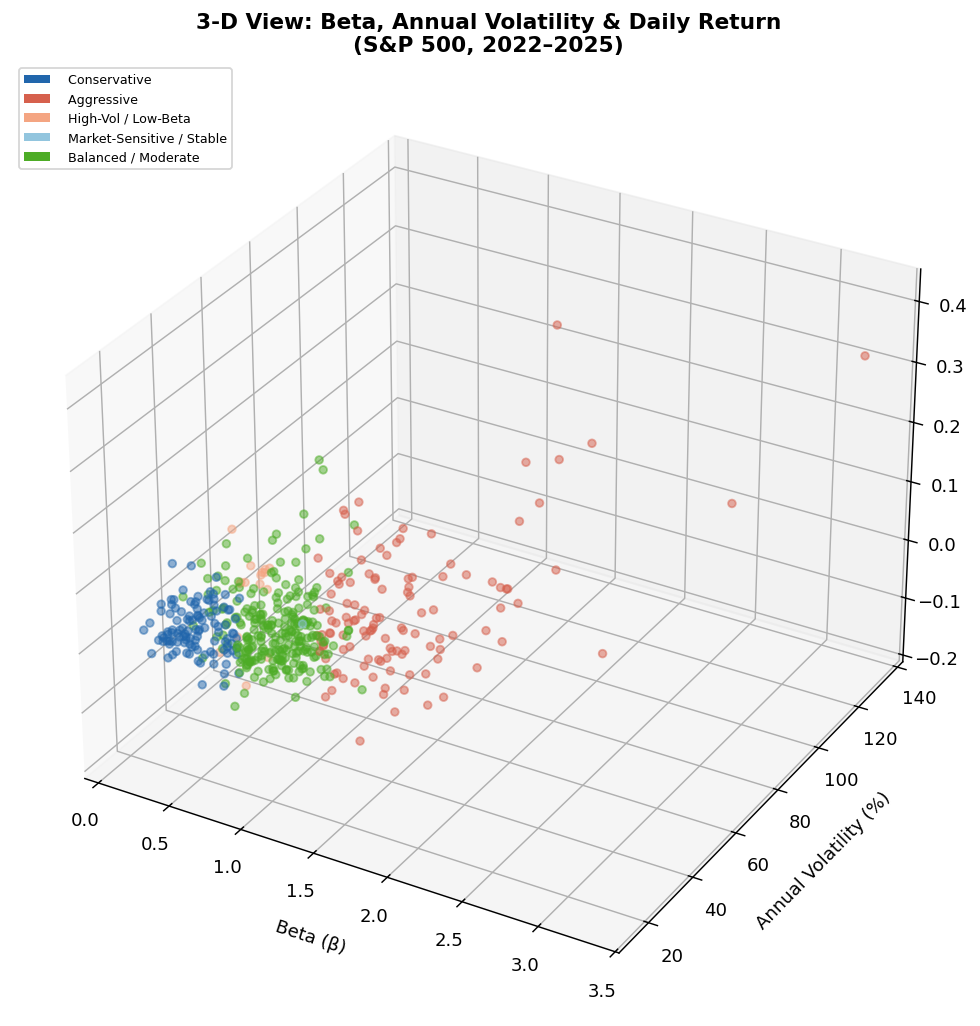

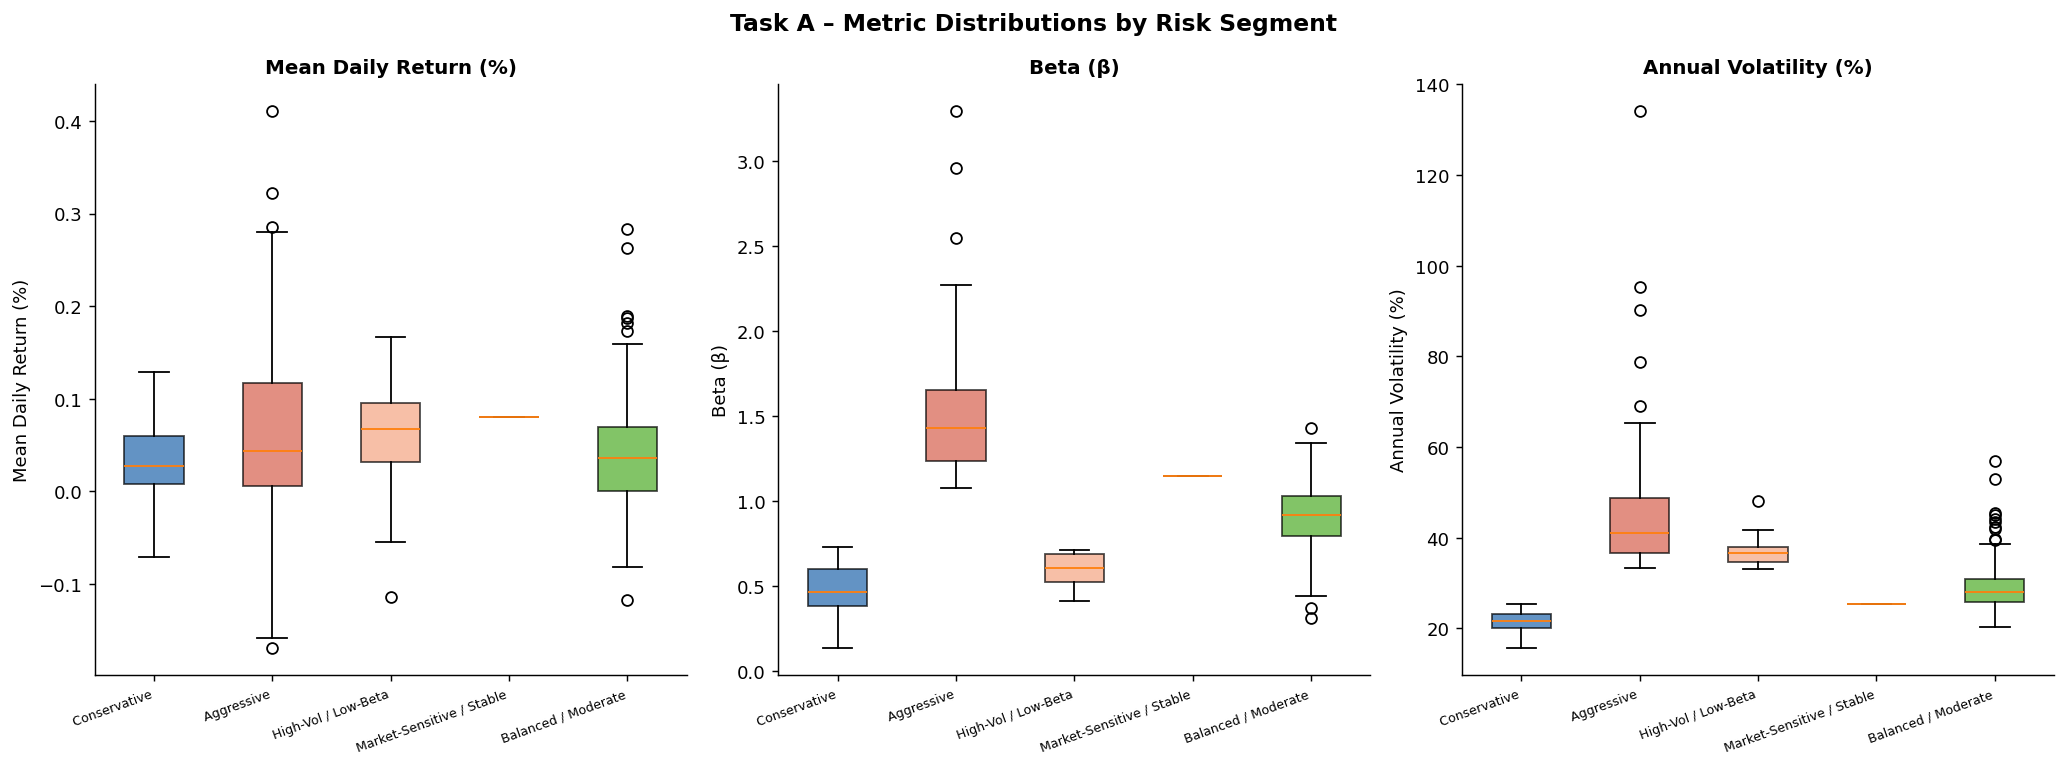

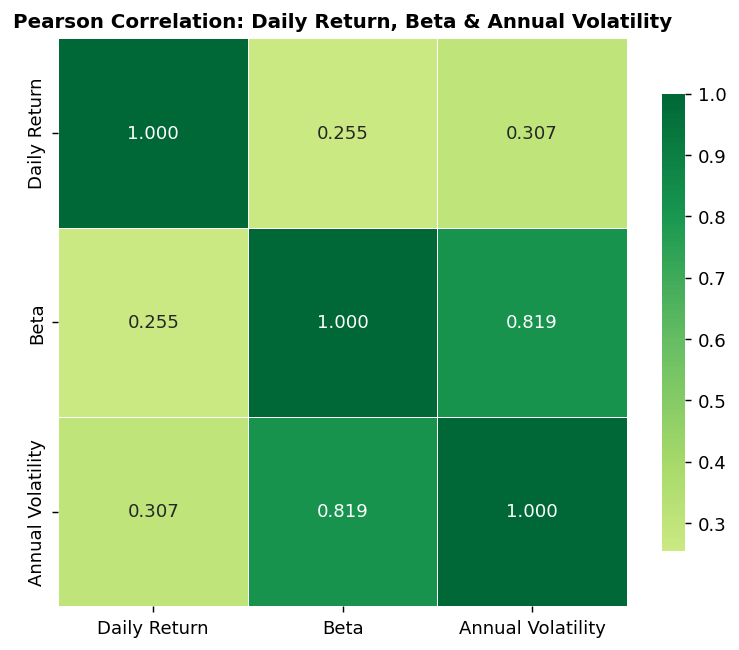

In [16]:
seg_palette = {
    "  Conservative"            : "#2166ac",
    "  Aggressive"               : "#d6604d",
    "  High-Vol / Low-Beta"      : "#f4a582",
    "  Market-Sensitive / Stable": "#92c5de",
    "  Balanced / Moderate"      : "#4dac26"
}

# Fig 1: Beta vs Annual Volatility
fig, ax = plt.subplots(figsize=(11, 7))
for seg, grp in metrics_df.groupby("Risk_Segment"):
    ax.scatter(grp["Beta"], grp["Annual_Volatility"] * 100,
               label=seg, alpha=0.6, s=25, color=seg_palette.get(seg, "grey"))
ax.axvline(1.0, color="black", lw=0.8, ls="--", alpha=0.5, label="β = 1")
ax.axhline(metrics_df["Annual_Volatility"].mean() * 100,
           color="grey", lw=0.8, ls=":", alpha=0.5, label="Mean Volatility")
ax.set_xlabel("Beta (β)", fontsize=11)
ax.set_ylabel("Annual Volatility (%)", fontsize=11)
ax.set_title("S&P 500 Stocks: Beta vs Annual Volatility\n(coloured by Risk Segment, 2022–2025)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.savefig("task_a_beta_vs_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

# Fig 2: Beta vs Daily Return
fig, ax = plt.subplots(figsize=(11, 7))
for seg, grp in metrics_df.groupby("Risk_Segment"):
    ax.scatter(grp["Beta"], grp["Mean_Daily_Return"] * 100,
               label=seg, alpha=0.6, s=25, color=seg_palette.get(seg, "grey"))
ax.axvline(1.0, color="black", lw=0.8, ls="--", alpha=0.5, label="β = 1")
ax.axhline(0, color="red", lw=0.8, ls="-", alpha=0.4, label="Zero return")
ax.set_xlabel("Beta (β)", fontsize=11)
ax.set_ylabel("Mean Daily Return (%)", fontsize=11)
ax.set_title("S&P 500 Stocks: Beta vs Mean Daily Return\n(coloured by Risk Segment, 2022–2025)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.savefig("task_a_beta_vs_return.png", dpi=150, bbox_inches="tight")
plt.show()

# Fig 3: 3-D scatter
from mpl_toolkits.mplot3d import Axes3D   # noqa

fig  = plt.figure(figsize=(12, 8))
ax3d = fig.add_subplot(111, projection="3d")
seg_colours_list = [seg_palette.get(s, "grey") for s in metrics_df["Risk_Segment"]]
ax3d.scatter(metrics_df["Beta"],
             metrics_df["Annual_Volatility"] * 100,
             metrics_df["Mean_Daily_Return"] * 100,
             c=seg_colours_list, alpha=0.5, s=18)
ax3d.set_xlabel("Beta (β)", labelpad=8)
ax3d.set_ylabel("Annual Volatility (%)", labelpad=8)
ax3d.set_zlabel("Mean Daily Return (%)", labelpad=8)
ax3d.set_title("3-D View: Beta, Annual Volatility & Daily Return\n(S&P 500, 2022–2025)",
               fontsize=12, fontweight="bold")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in seg_palette.items()]
ax3d.legend(handles=legend_elements, loc="upper left", fontsize=7, framealpha=0.8)
plt.tight_layout()
plt.savefig("task_a_3d_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# Fig 4: Box plots by Risk Segment
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (col, label, scale) in zip(axes, [
    ("Mean_Daily_Return", "Mean Daily Return (%)", 100),
    ("Beta",              "Beta (β)",               1),
    ("Annual_Volatility", "Annual Volatility (%)", 100)
]):
    labels_present  = [s for s in seg_palette.keys() if s in metrics_df["Risk_Segment"].values]
    colours_present = [seg_palette[s] for s in labels_present]
    data_by_seg     = [metrics_df.loc[metrics_df["Risk_Segment"] == s, col].values * scale
                       for s in labels_present]
    bp = ax.boxplot(data_by_seg, patch_artist=True, notch=False, vert=True)
    for patch, c in zip(bp["boxes"], colours_present):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(labels_present) + 1))
    ax.set_xticklabels(labels_present, rotation=20, ha="right", fontsize=7)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontweight="bold", fontsize=11)

plt.suptitle("Task A – Metric Distributions by Risk Segment", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("task_a_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Fig 5: Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
corr = metrics_df[["Mean_Daily_Return","Beta","Annual_Volatility"]].corr()
corr.index   = ["Daily Return","Beta","Annual Volatility"]
corr.columns = ["Daily Return","Beta","Annual Volatility"]
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation: Daily Return, Beta & Annual Volatility",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("task_a_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Part C-2: Clusters Visualisations (for parts A and C)

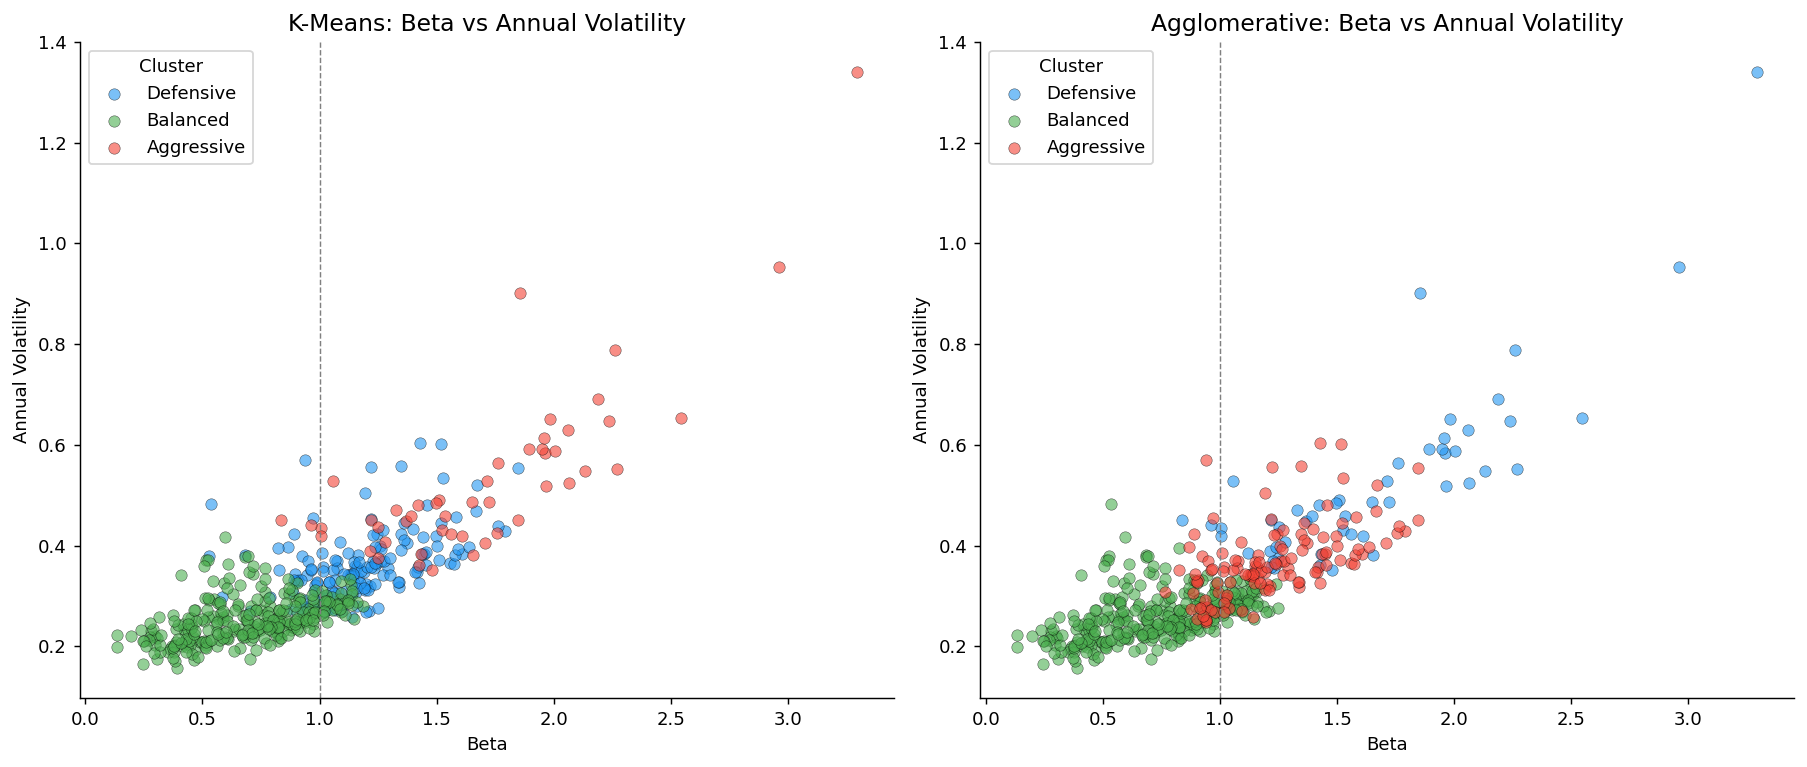

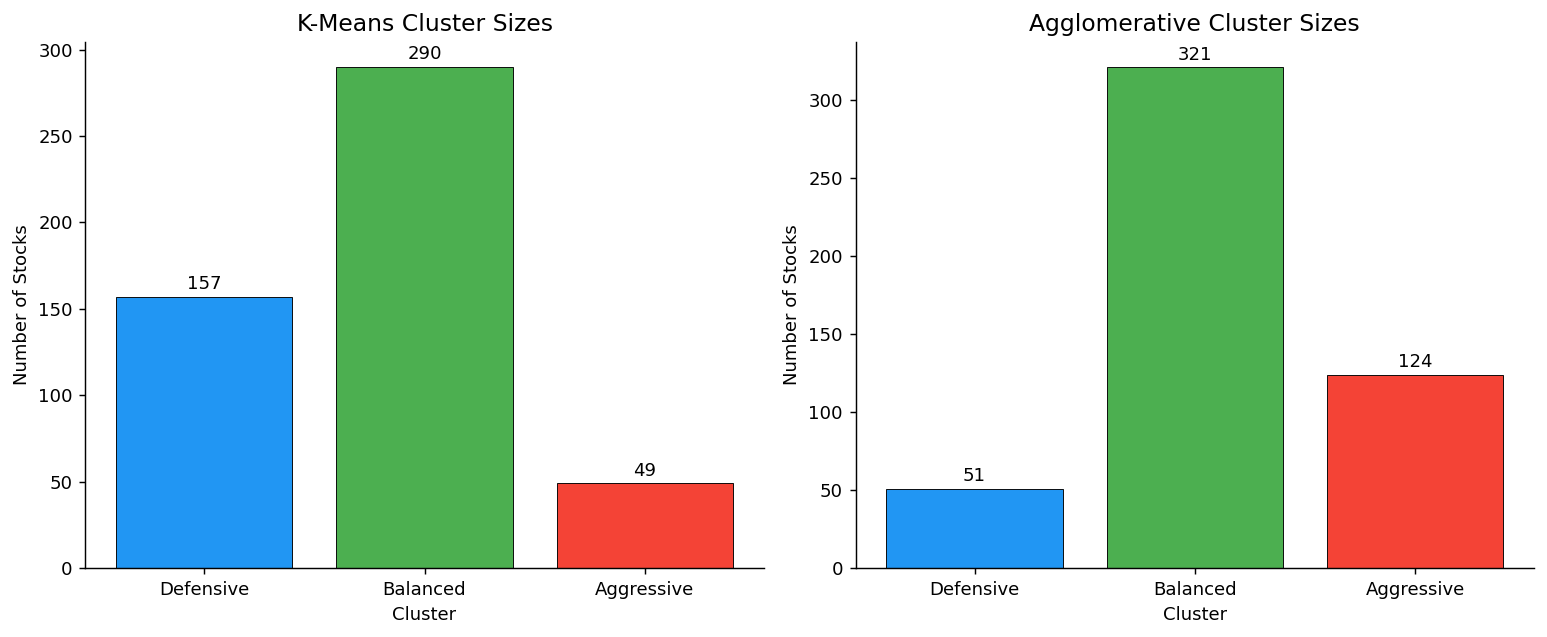

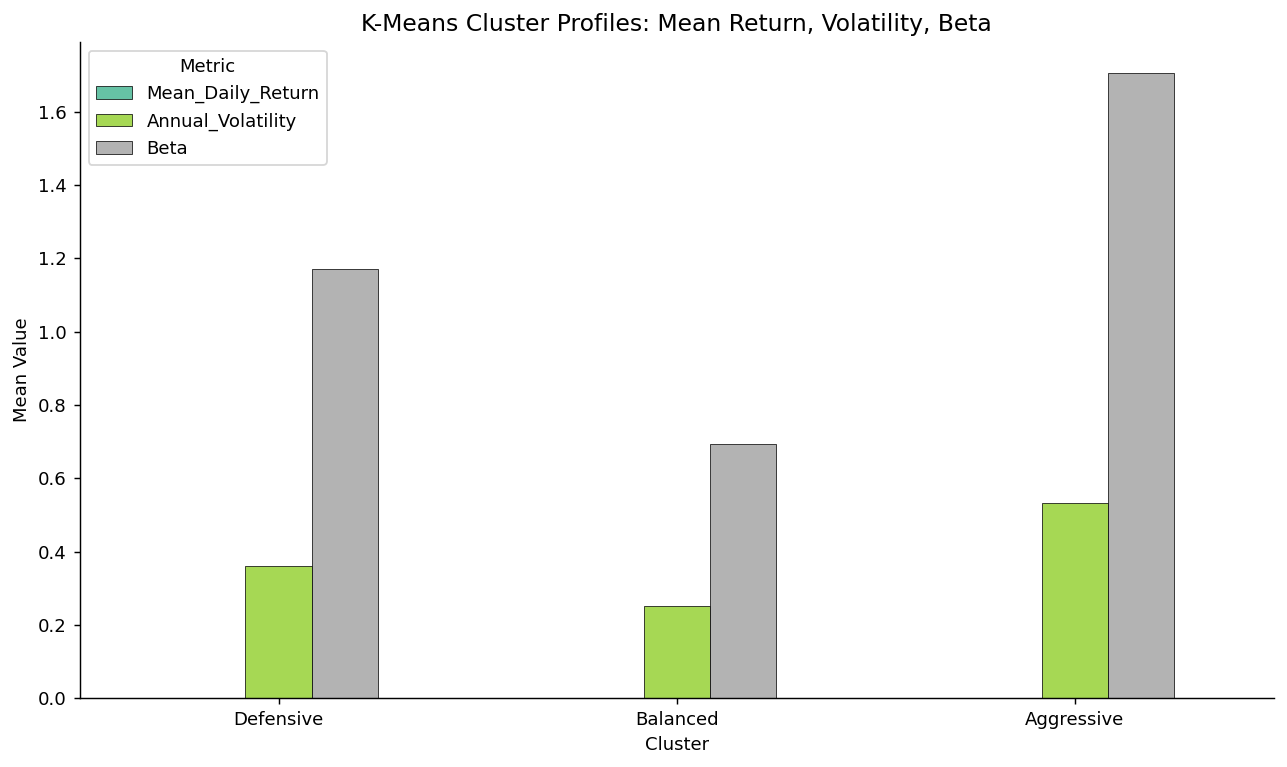

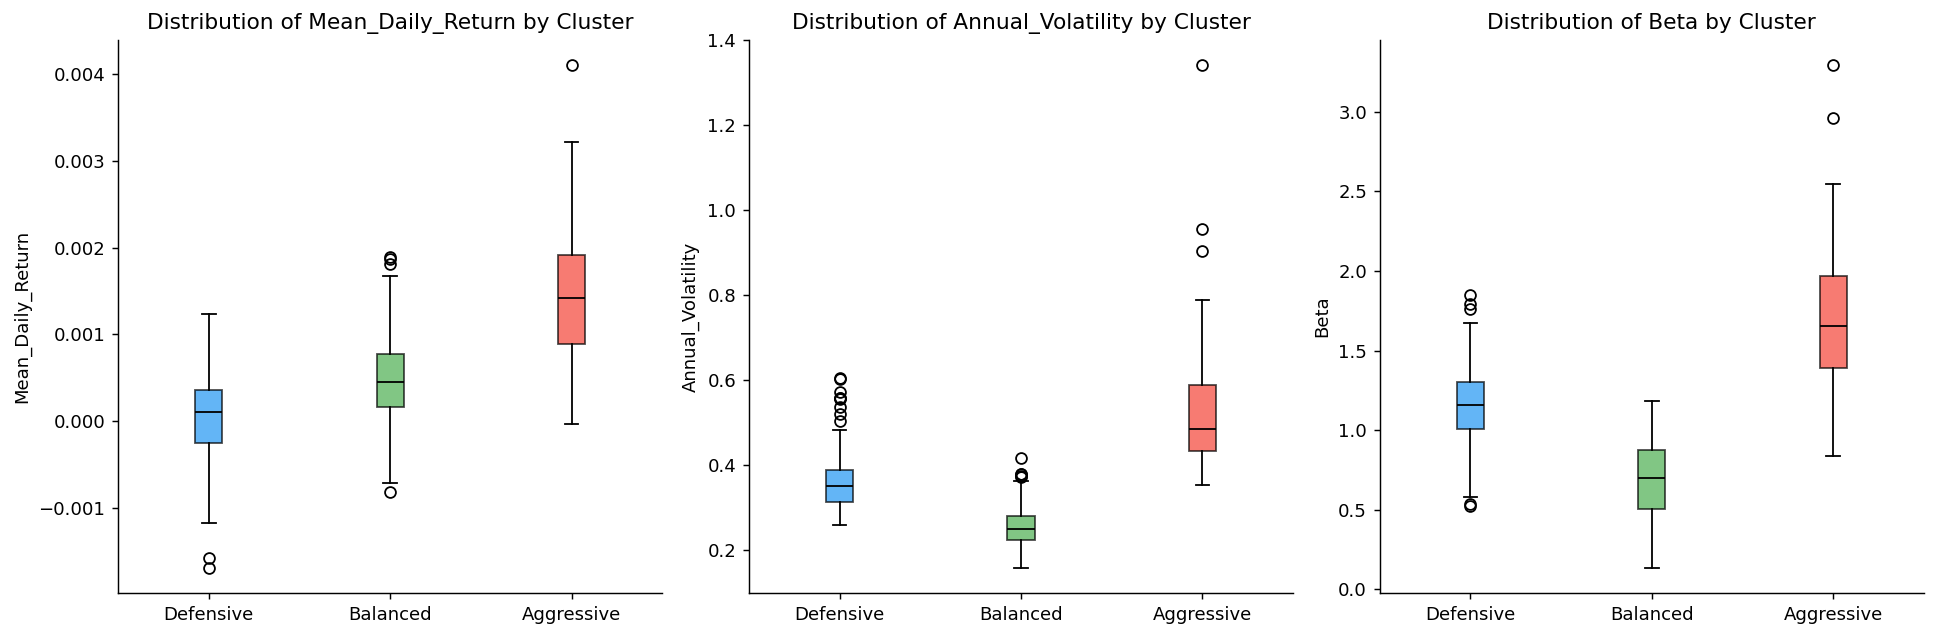

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Cluster labels
cluster_names = {0: "Defensive", 1: "Balanced", 2: "Aggressive"}
palette = {0: "#2196F3", 1: "#4CAF50", 2: "#F44336"}

# Plot 1: Beta vs Annual Volatility (K-Means)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cluster_id, group in df_features.groupby("KMeans_Cluster"):
    axes[0].scatter(
        group["Beta"], group["Annual_Volatility"],
        label=cluster_names[cluster_id],
        color=palette[cluster_id],
        alpha=0.6, edgecolors="k", linewidths=0.3, s=40
    )

axes[0].set_title("K-Means: Beta vs Annual Volatility", fontsize=13)
axes[0].set_xlabel("Beta")
axes[0].set_ylabel("Annual Volatility")
axes[0].legend(title="Cluster")
axes[0].axvline(1, color="grey", linestyle="--", linewidth=0.8, label="Beta = 1")

# Plot 2: Beta vs Annual Volatility (Agglomerative)
for cluster_id, group in df_features.groupby("Cluster"):
    axes[1].scatter(
        group["Beta"], group["Annual_Volatility"],
        label=cluster_names[cluster_id],
        color=palette[cluster_id],
        alpha=0.6, edgecolors="k", linewidths=0.3, s=40
    )

axes[1].set_title("Agglomerative: Beta vs Annual Volatility", fontsize=13)
axes[1].set_xlabel("Beta")
axes[1].set_ylabel("Annual Volatility")
axes[1].legend(title="Cluster")
axes[1].axvline(1, color="grey", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 3: Cluster size comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ["KMeans_Cluster", "Cluster"],
    ["K-Means Cluster Sizes", "Agglomerative Cluster Sizes"]
):
    counts = df_features[col].value_counts().sort_index()
    colors = [palette[i] for i in counts.index]
    bars = ax.bar(
        [cluster_names[i] for i in counts.index],
        counts.values,
        color=colors, edgecolor="k", linewidth=0.5
    )
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(v), ha="center", va="bottom", fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Number of Stocks")

plt.tight_layout()
plt.savefig("cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 4: Cluster profile radar / bar chart
kmeans_profile = df_features.groupby("KMeans_Cluster")[["Mean_Daily_Return", "Annual_Volatility", "Beta"]].mean()
kmeans_profile.index = [cluster_names[i] for i in kmeans_profile.index]

ax = kmeans_profile.plot(kind="bar", figsize=(10, 6), colormap="Set2", edgecolor="k", linewidth=0.4)
ax.set_title("K-Means Cluster Profiles: Mean Return, Volatility, Beta", fontsize=13)
ax.set_xlabel("Cluster")
ax.set_ylabel("Mean Value")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Metric")
plt.tight_layout()
plt.savefig("cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 5: Box plots of Volatility by KMeans cluster
df_plot = df_features.copy()
df_plot["Cluster Label"] = df_plot["KMeans_Cluster"].map(cluster_names)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ["Mean_Daily_Return", "Annual_Volatility", "Beta"]):
    order = ["Defensive", "Balanced", "Aggressive"]
    colors = ["#2196F3", "#4CAF50", "#F44336"]
    for i, (cat, color) in enumerate(zip(order, colors)):
        data = df_plot[df_plot["Cluster Label"] == cat][metric]
        bp = ax.boxplot(data, positions=[i], patch_artist=True,
                        boxprops=dict(facecolor=color, alpha=0.7),
                        medianprops=dict(color="black"))
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(order)
    ax.set_title(f"Distribution of {metric} by Cluster")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.savefig("cluster_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()